In [8]:
import sys
sys.path.append('../../')
import numpy as np

from samrfi import RadioRFI, RFIDataset, RFITraining

In [2]:
from samrfi import RadioRFI

dir_path = '/home/gpuhost002/ddeal/RFI-AI/'

original_calib = '/home/gpuhost002/ddeal/RFI-AI/original_calib/calib_phase_tfcrop_twice.ms'

datarfi_3C147 = RadioRFI(vis=original_calib, dir_path=dir_path)
datarfi_3C147.load(mode='DATA', ant_i=1) # using first two antennas


Loading data...


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:43<00:00, 43.38s/it]


(26, 4, 2048, 196)


In [3]:
datarfi_3C147.load(mode='FLAG', ant_i=1) # using first two antennas
datarfi_3C147.flags = np.abs(datarfi_3C147.ms_flags)


Loading data...


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:20<00:00, 20.13s/it]


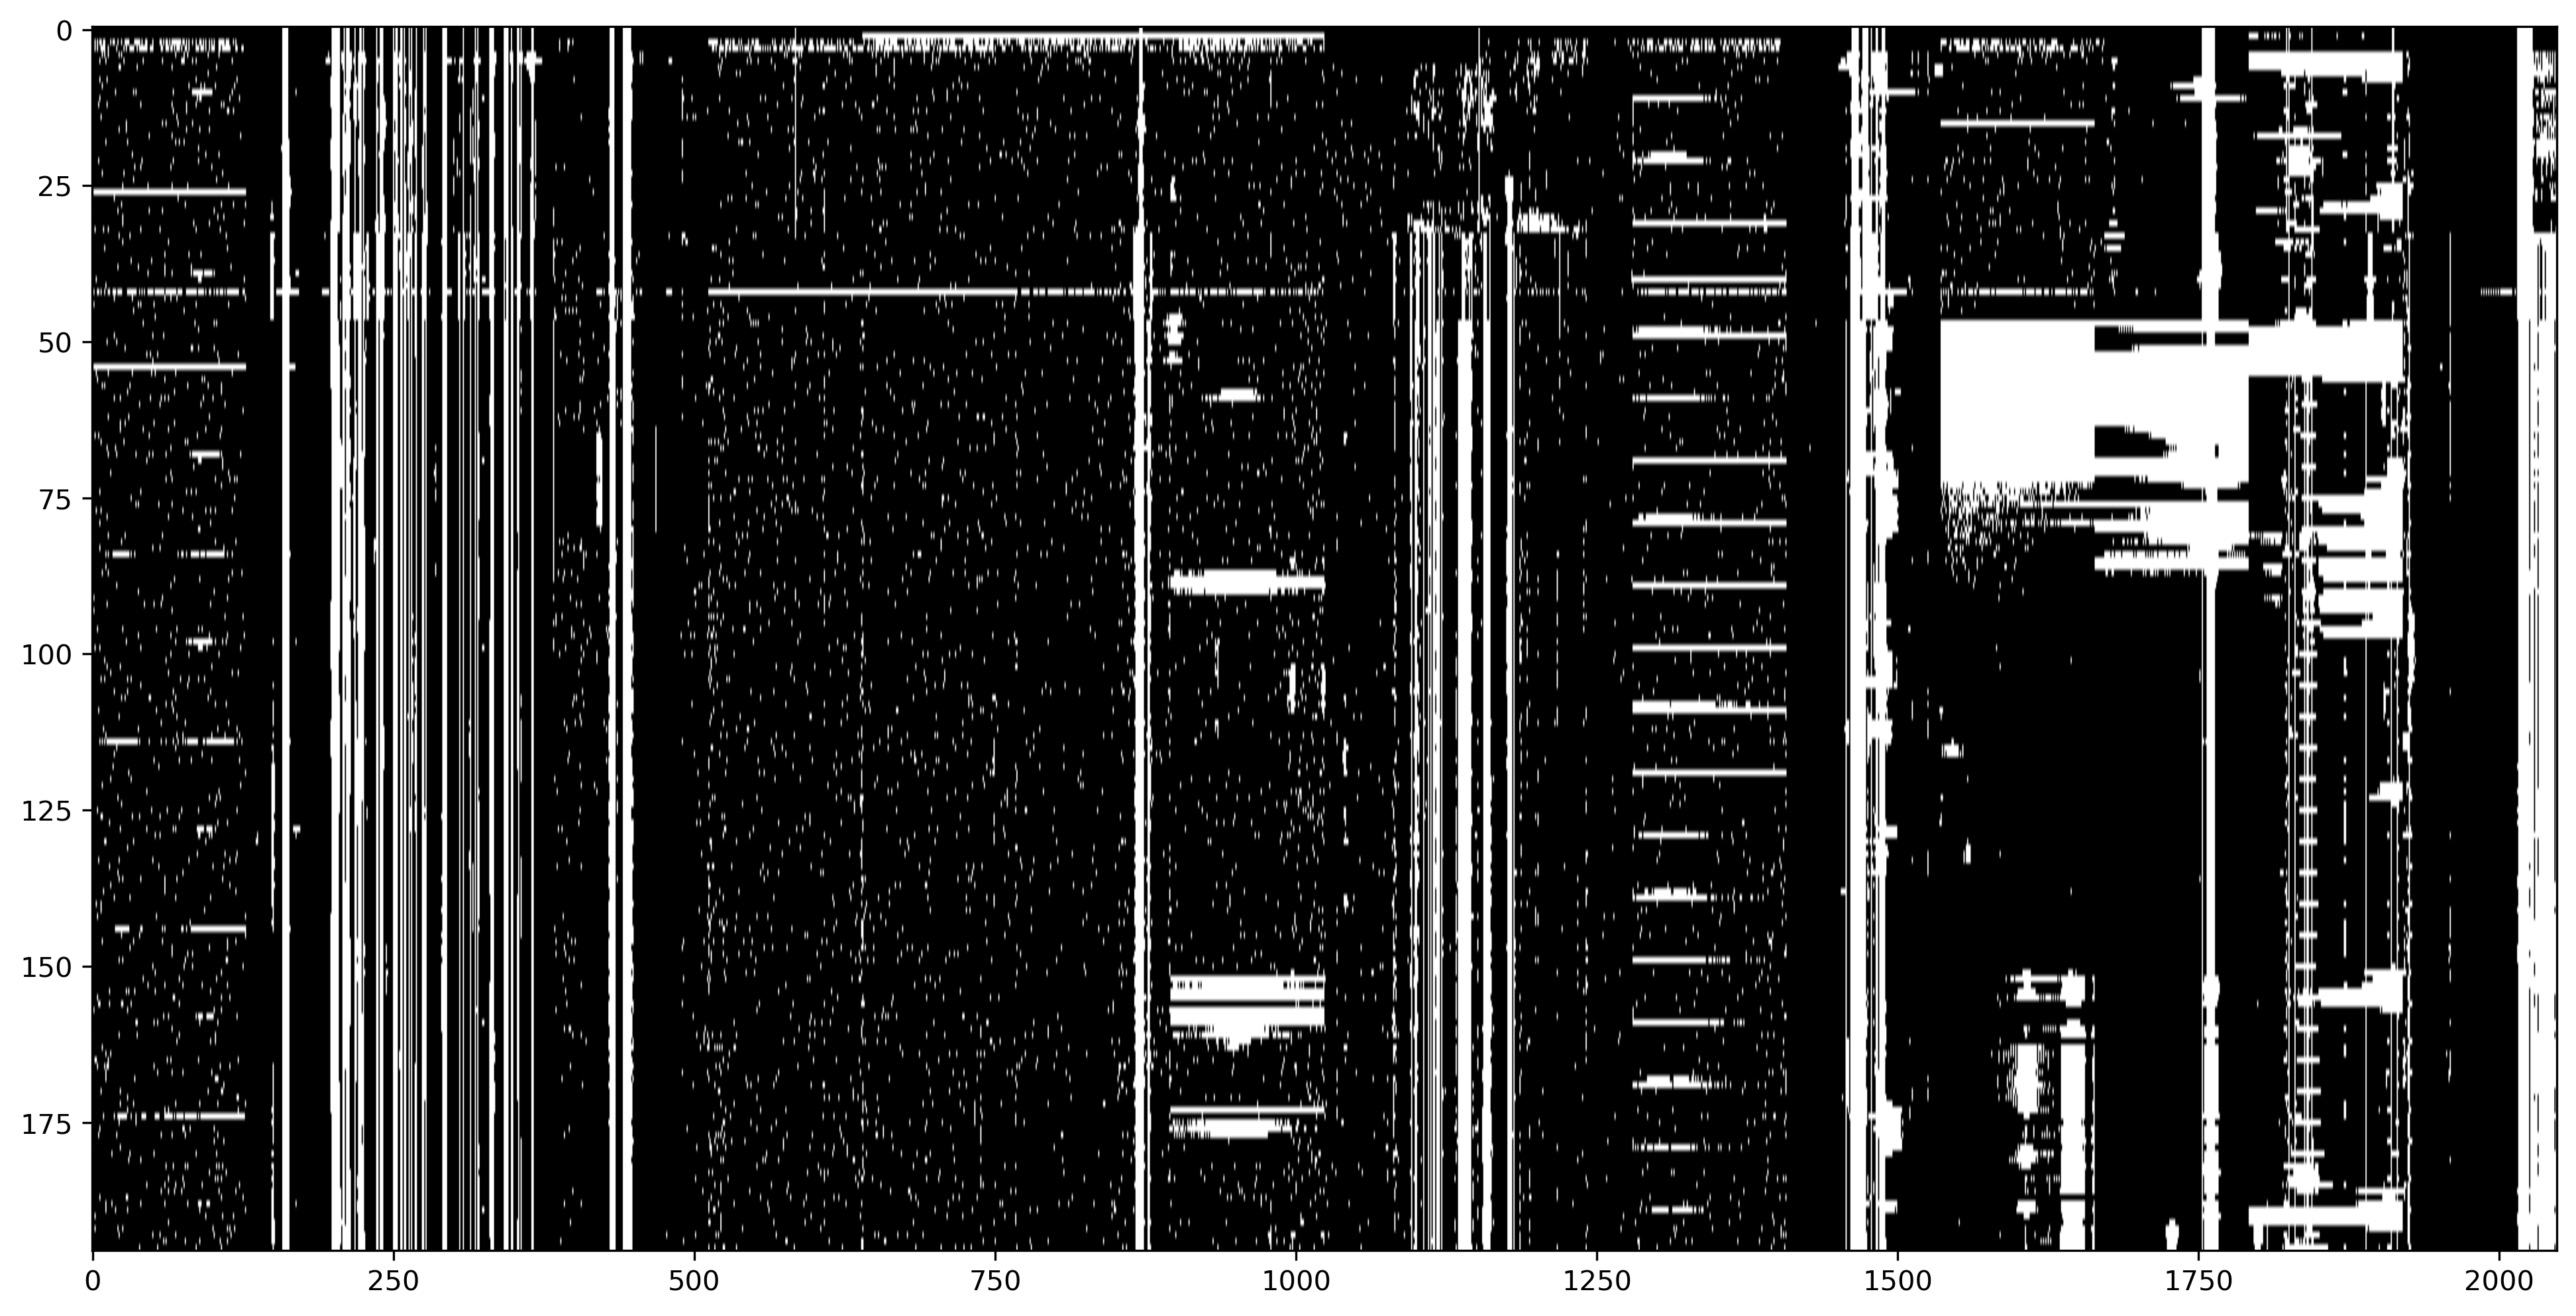

In [25]:
datarfi_3C147.plotter.plot(mode='FLAG', baseline=8, polarization=0)

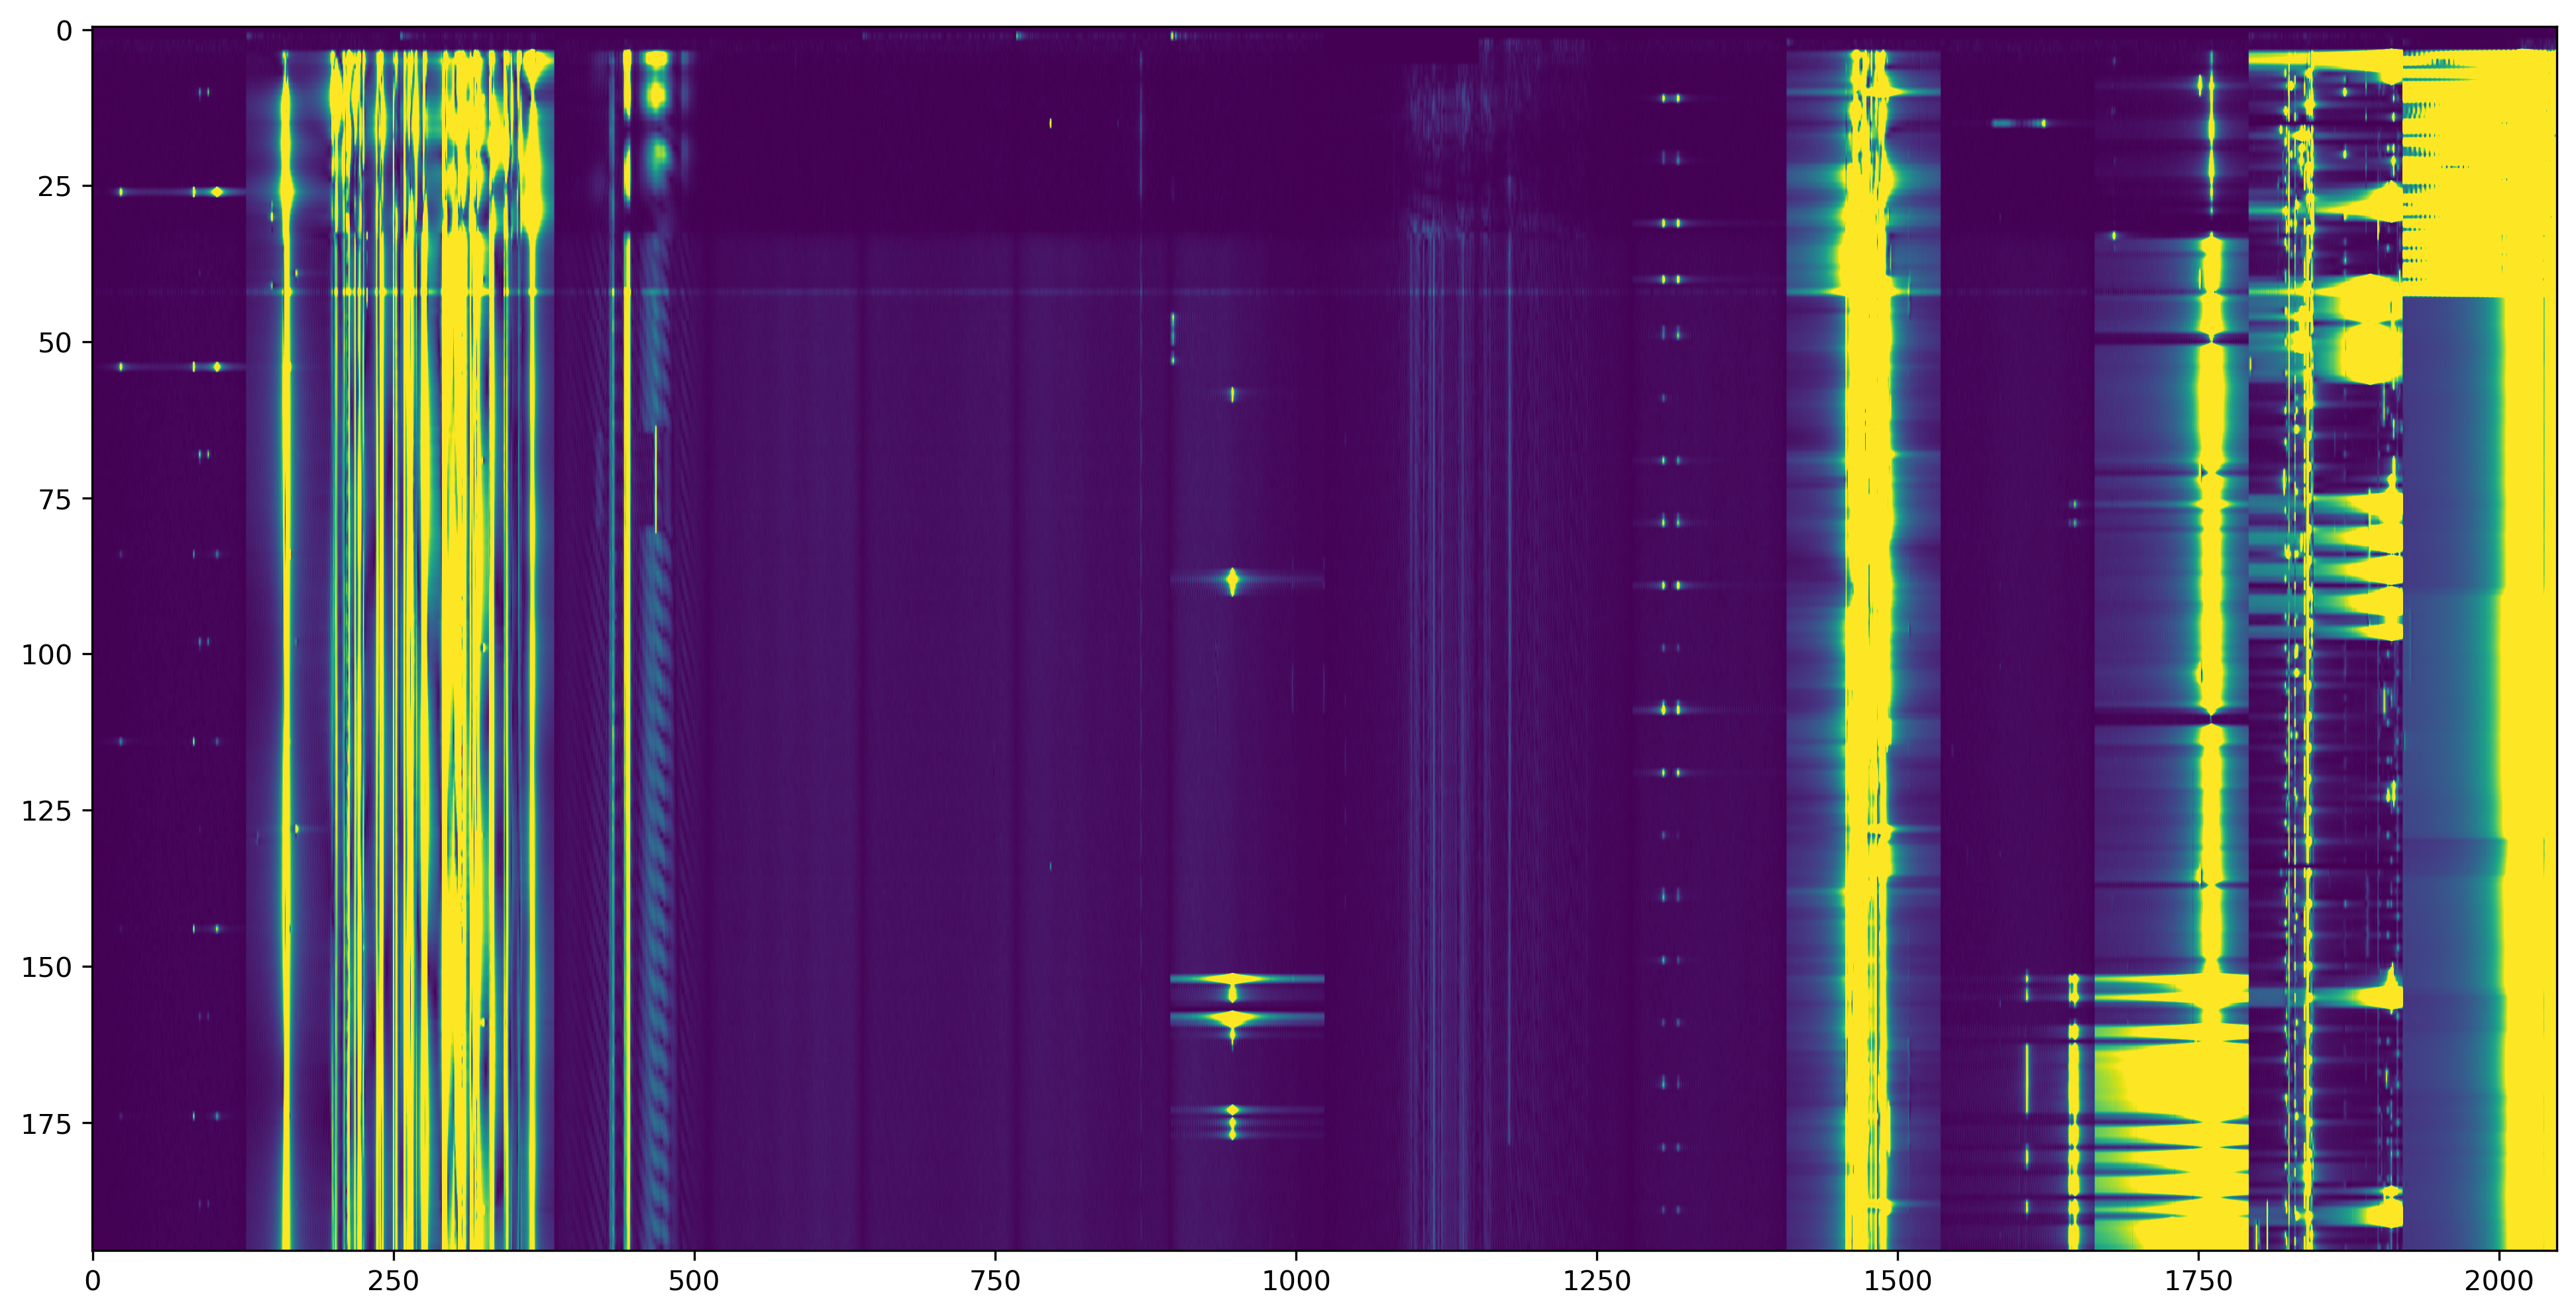

In [26]:
datarfi_3C147.plotter.plot(mode='DATA', baseline=8, polarization=0)

In [4]:
# datarfi_3C147.rfi_antenna_data = datarfi_3C147.rfi_antenna_data[0:2]
# datarfi_3C147.flags = datarfi_3C147.flags[0:2]

In [5]:
datarfi_3C147.rfi_antenna_data.shape

(51, 4, 2048, 196)

In [6]:
datarfi_3C147.flags.shape

(51, 4, 2048, 196)

In [4]:
reflected_part = np.flip(datarfi_3C147.rfi_antenna_data, axis=-1)  # Alternatively, use arr[..., ::-1]
# Step 2: Concatenate along the last axis
new_arr = np.concatenate((datarfi_3C147.rfi_antenna_data, reflected_part), axis=-1)
datarfi_3C147.rfi_antenna_data = new_arr

datarfi_3C147.flags = np.abs(datarfi_3C147.ms_flags)

reflected_part = np.flip(datarfi_3C147.flags, axis=-1)  # Alternatively, use arr[..., ::-1]
# Step 2: Concatenate along the last axis
new_arr = np.concatenate((datarfi_3C147.flags, reflected_part), axis=-1)
datarfi_3C147.flags = new_arr

In [39]:
datarfi_3C147.flags.shape, datarfi_3C147.rfi_antenna_data.shape

((26, 4, 2048, 392), (26, 4, 2048, 392))

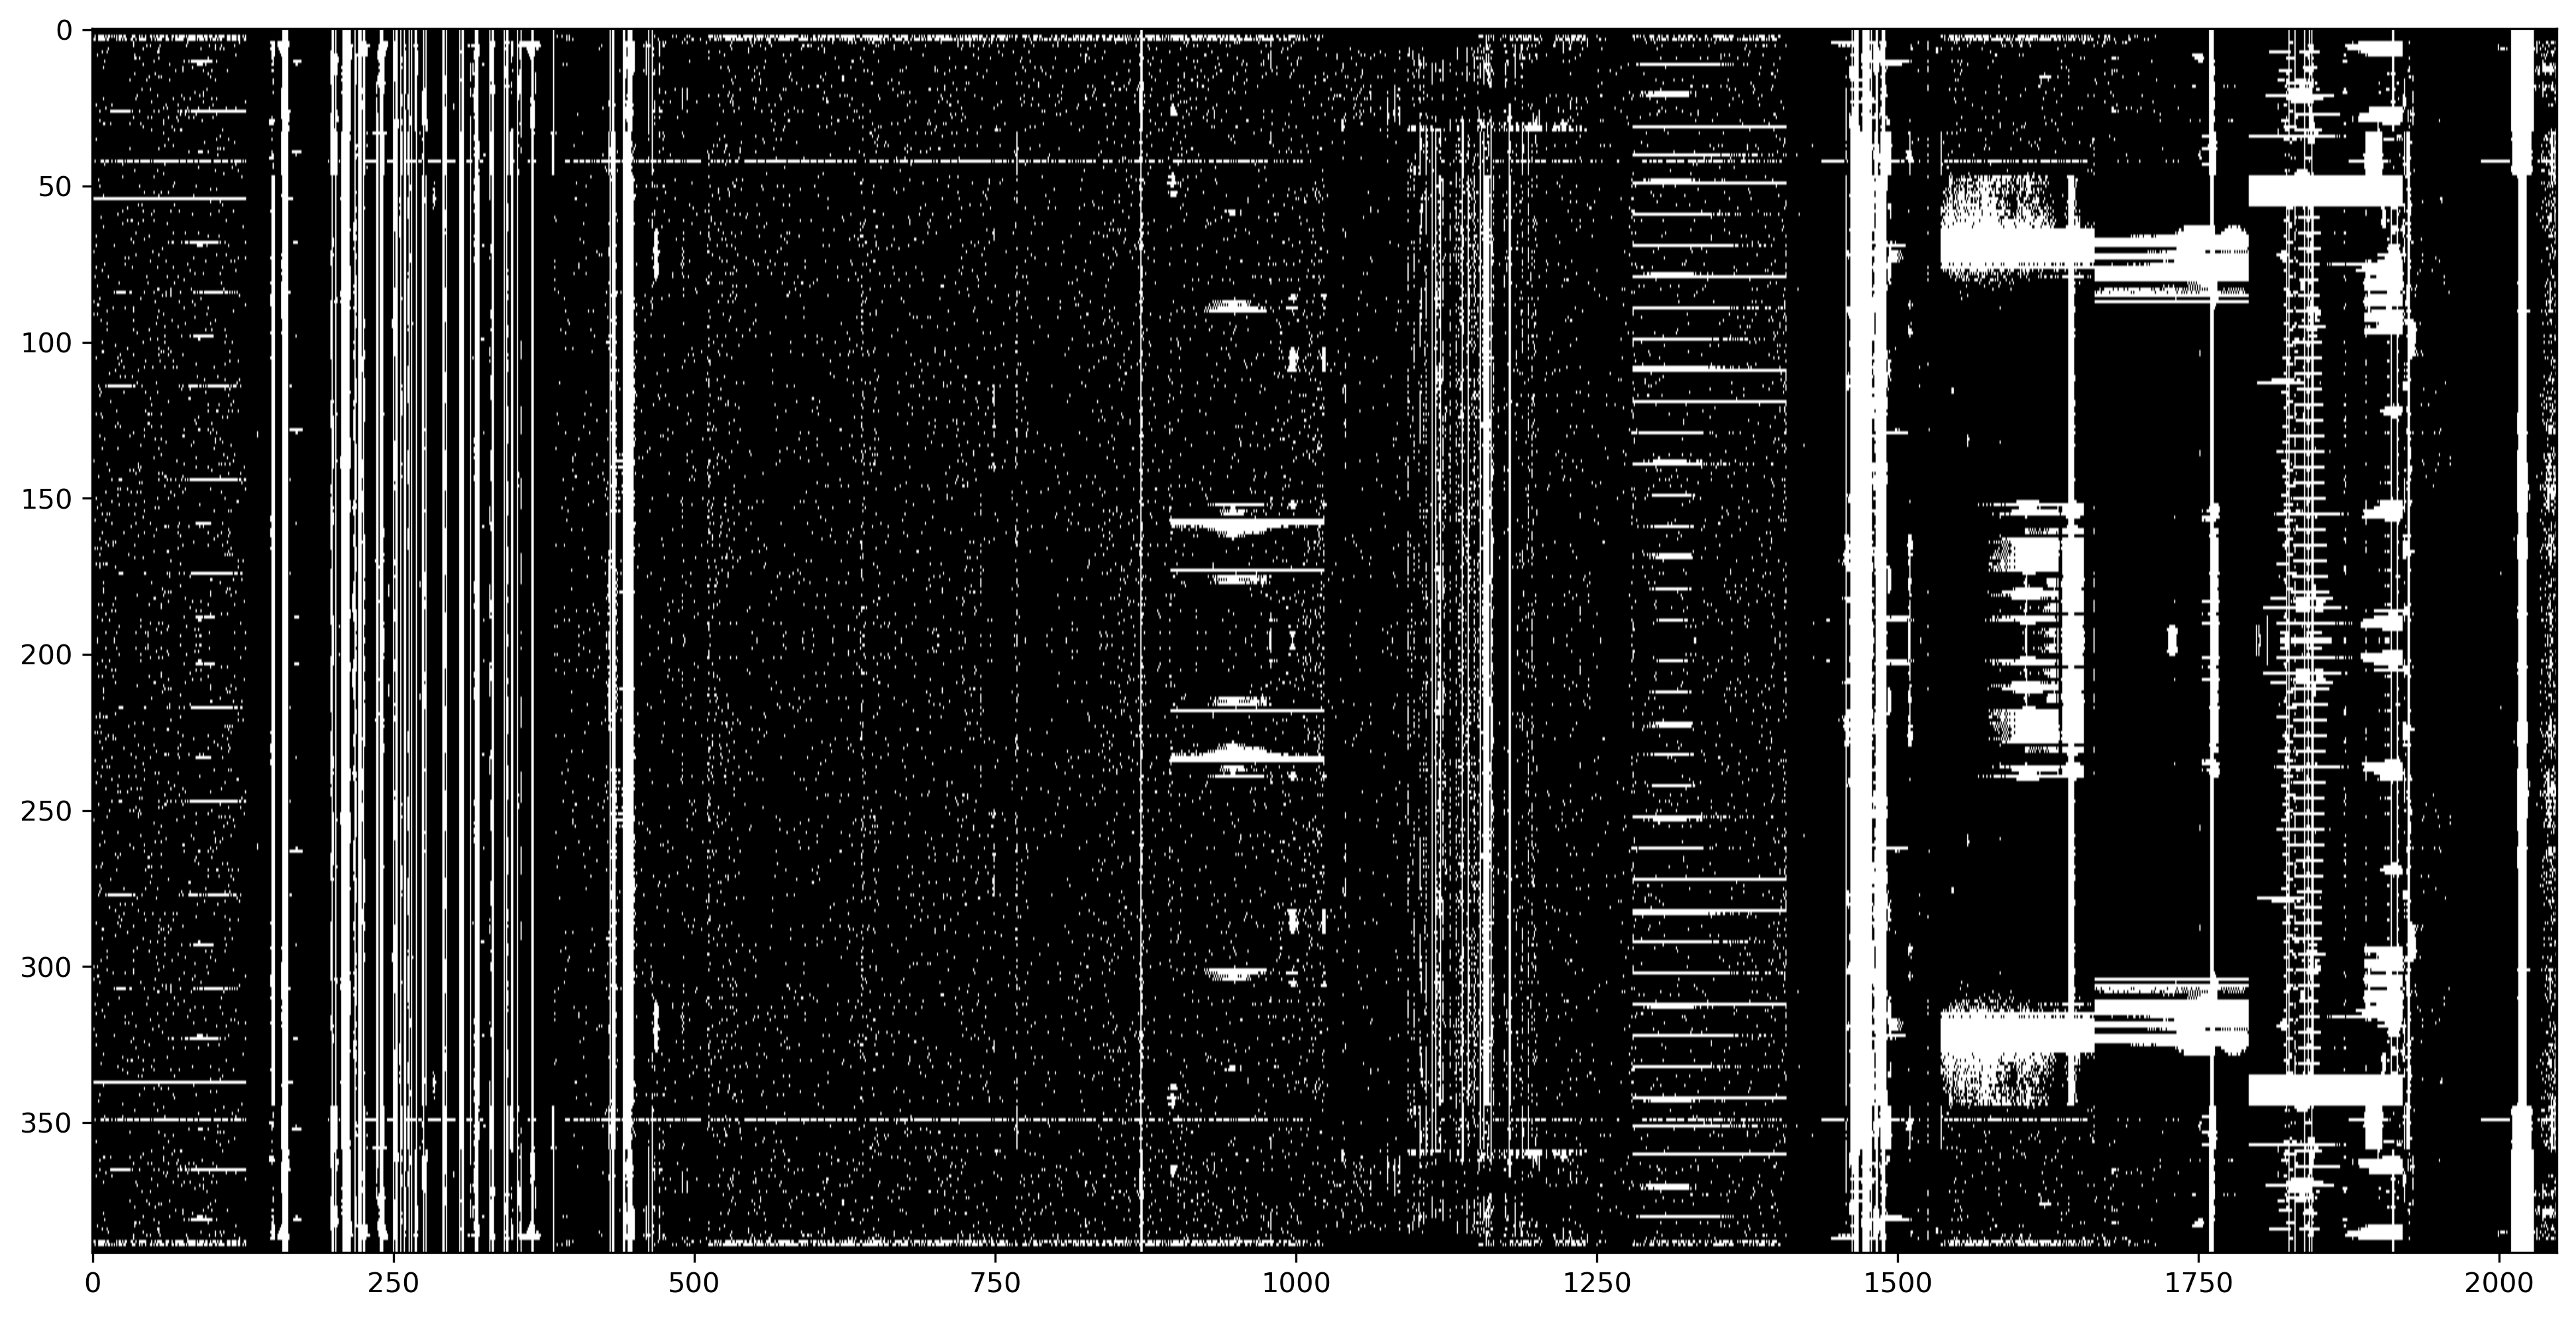

In [7]:
datarfi_3C147.plotter.plot(mode='FLAG', baseline=1, polarization=0)

In [5]:
rfi_dataset = RFIDataset(datarfi_3C147, dir_path=dir_path)
rfi_dataset.create_dataset(patch_size=256, apply_stretching=False, custom_flag=True,)


Applying median normalization only to 3328 patches...


 65%|██████▌   | 2179/3328 [00:02<00:01, 818.38it/s]

100%|██████████| 3328/3328 [00:03<00:00, 875.93it/s]



Applying median normalization only to 3328 patches...


100%|█████████▉| 3316/3328 [00:03<00:00, 894.22it/s]


KeyboardInterrupt: 

In [35]:
cd /home/gpuhost002/ddeal/RFI-AI/sam2/notebooks

/home/gpuhost002/ddeal/RFI-AI/sam2/notebooks



Training SAM 2 model...


3328it [06:52,  8.07it/s]


Epoch 2/60, Loss: 0.41186755201152453


3328it [06:53,  8.04it/s]


Epoch 3/60, Loss: 0.4114361781035908


...

3328it [06:54,  8.03it/s]


Epoch 60/60, Loss: 0.04777856398588763


3328it [06:50,  8.11it/s]


Epoch 61/60, Loss: 0.04640203089533875


<Figure size 640x480 with 0 Axes>

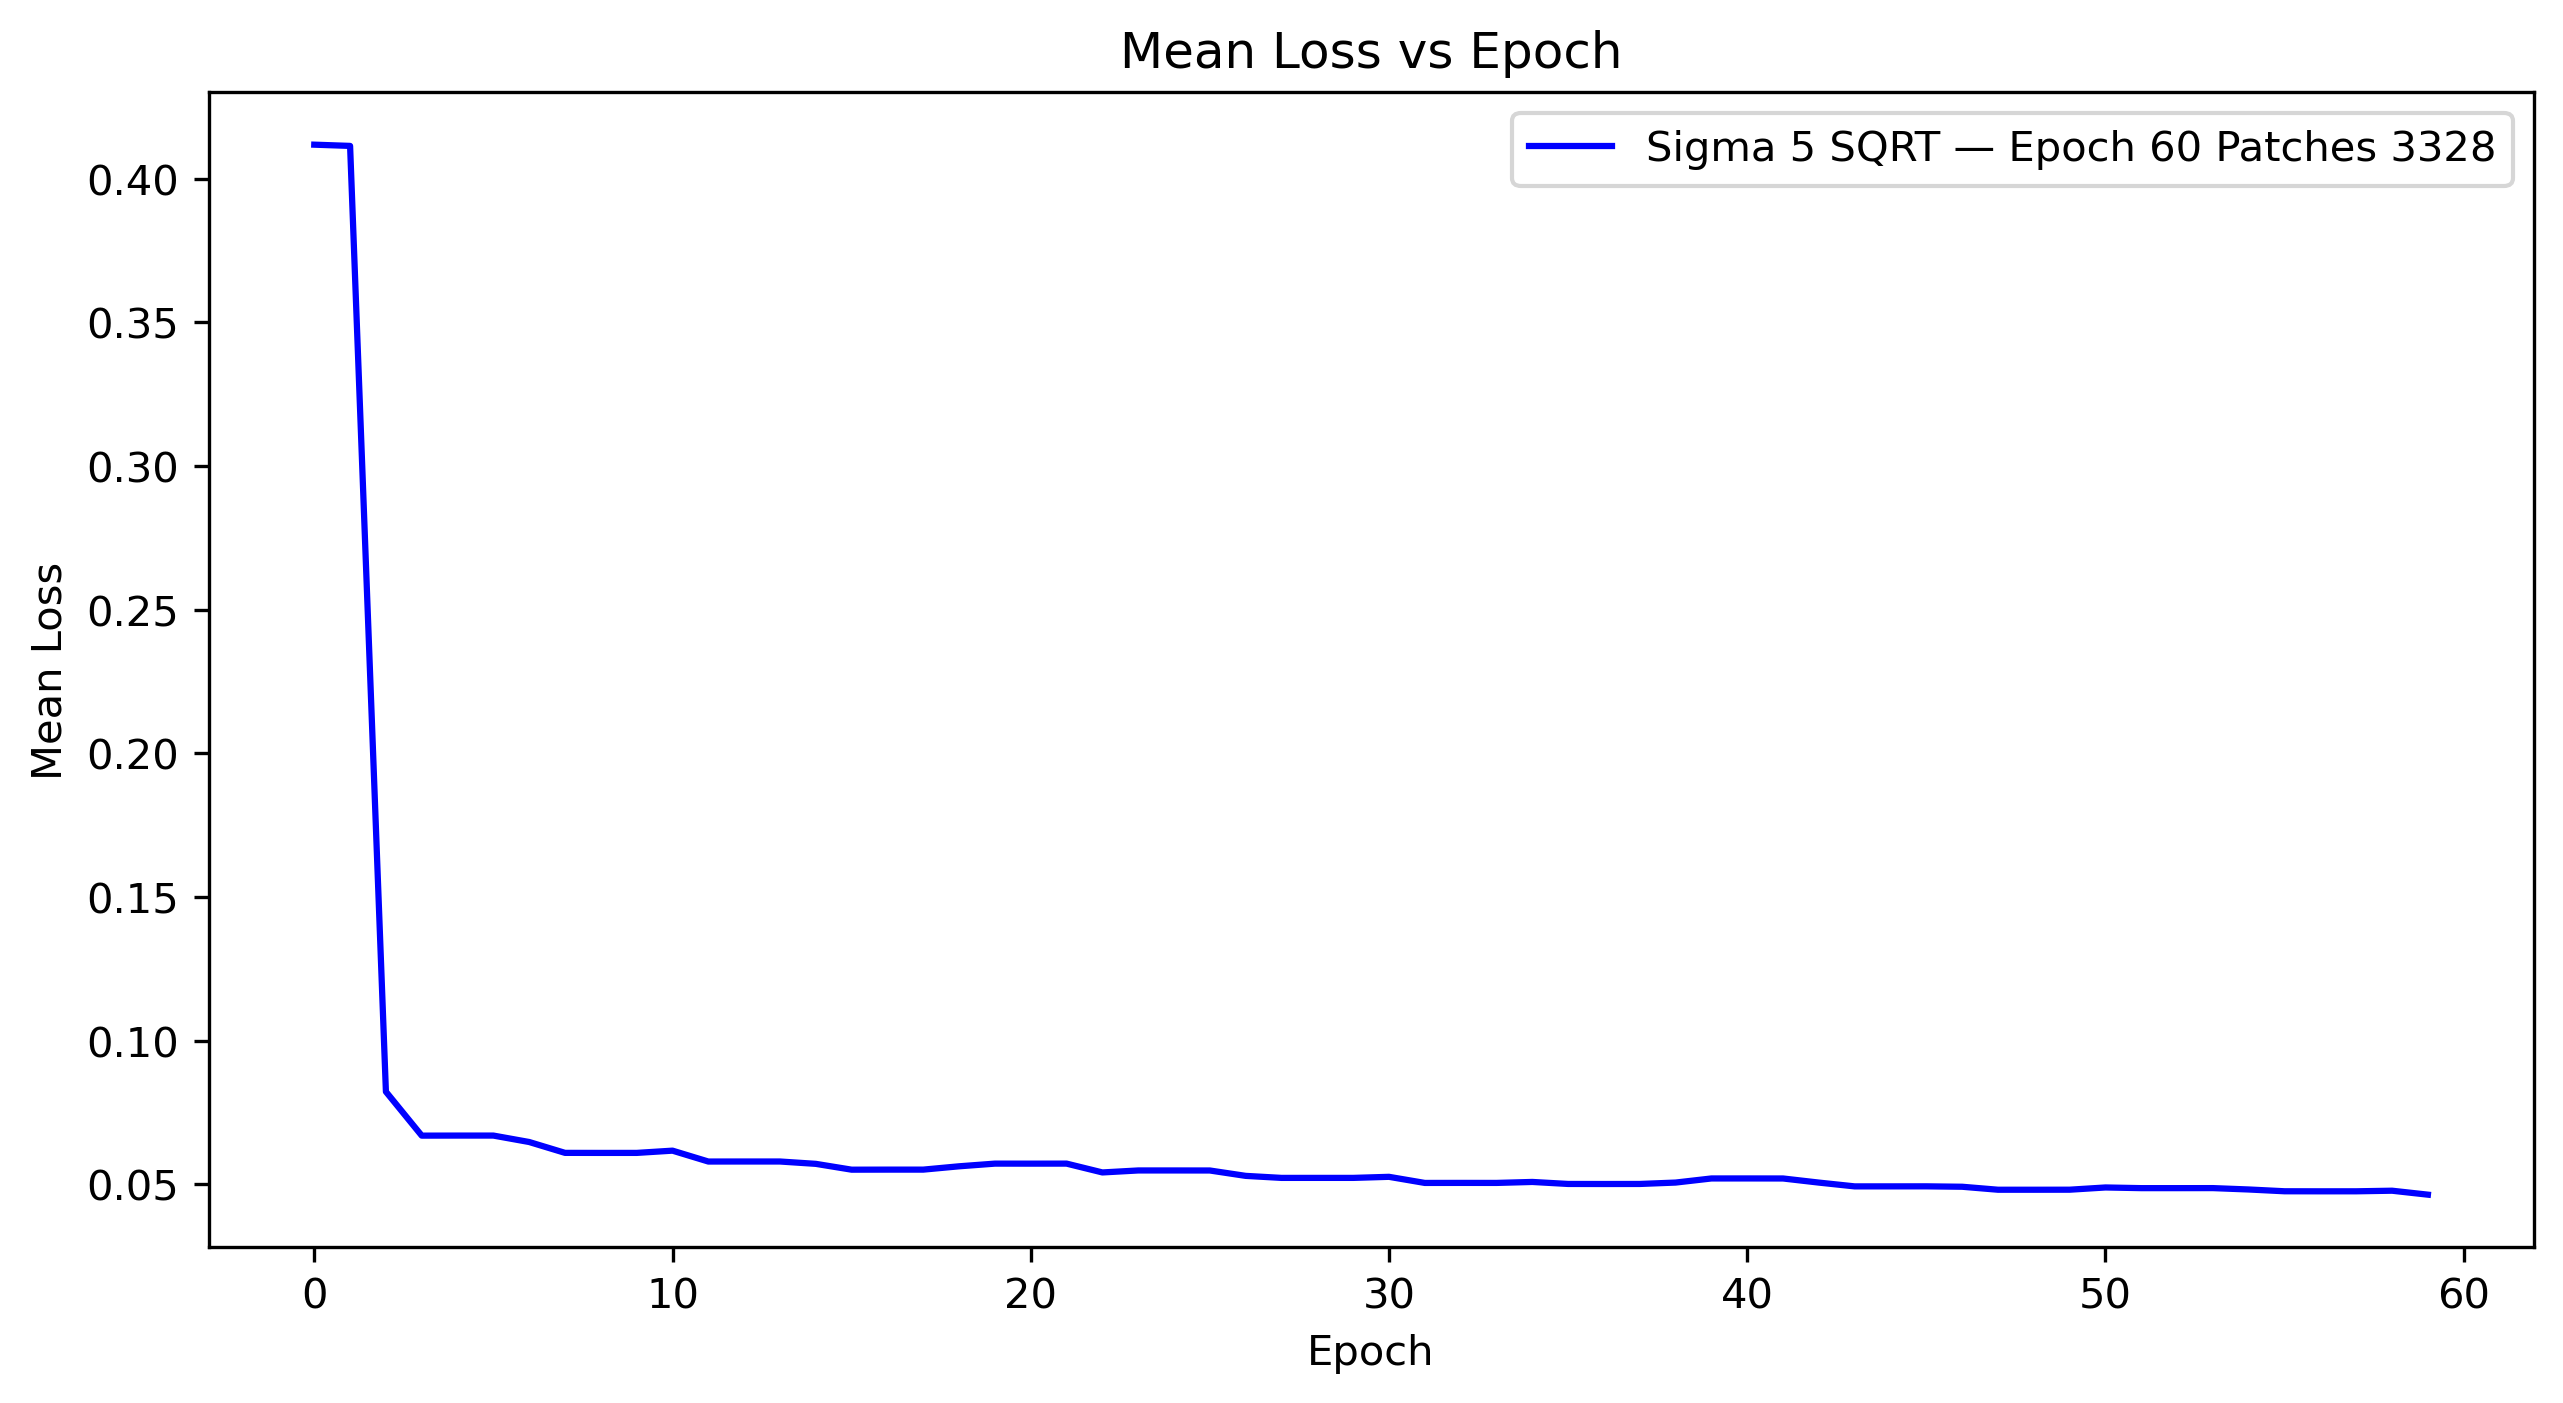

In [42]:
new_model_sam2 = RFITraining(rfi_dataset, device='cuda', dir_path=dir_path)

new_model_sam2.sam2_ckpt = "../checkpoints/sam2.1_hiera_large.pt"
new_model_sam2.sam2_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"
new_model_sam2.train_sam2(num_epochs=13, batch_size=None, step_size=500, num_points=512)